In [6]:
!pip install stable-baselines3[extra]
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git
!pip install websockets>=15.0.0 --quiet
!pip install transformers --quiet
!pip install polygon-api-client --quiet

zsh:1: no matches found: stable-baselines3[extra]
  Cloning https://github.com/AI4Finance-Foundation/FinRL.git to /private/var/folders/sc/40gcq14x2cng8czg1s_vpkbr0000gn/T/pip-req-build-4640cmxh
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/FinRL.git /private/var/folders/sc/40gcq14x2cng8czg1s_vpkbr0000gn/T/pip-req-build-4640cmxh
  Resolved https://github.com/AI4Finance-Foundation/FinRL.git to commit f4283de63ca73c915321c5555fa3751698a61eec
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/AI4Finance-Foundation/ElegantRL.git to /private/var/folders/sc/40gcq14x2cng8czg1s_vpkbr0000gn/T/pip-install-o1i4t1fy/elegantrl_d6e50105afe24e7aa660b1410a4c0d42
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/ElegantRL.git /private/var/folders/sc/40gcq14x2cng8czg1s_vpkbr0000gn/T/pip-install-o1i4

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
import pkg_resources
import yfinance as yf
from datetime import timedelta, date
from polygon import RESTClient
from transformers import BertTokenizer, BertForSequenceClassification
import torch as th
import torch.nn as nn

import stable_baselines3
import finrl

import sys
sys.path.append('.')
from utils import (
    prepare_df, compute_metrics, compute_rolling_metrics,
    plot_metrics, compute_buy_and_hold, overfitting_check,
    check_degenerate_policy, check_lookahead_bias,
    regime_analysis, run_full_evaluation
)

from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer
from finrl.agents.stablebaselines3.models import DRLAgent
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.config import INDICATORS

%matplotlib inline
plt.close('all')

print(f"SB3 Version:    {stable_baselines3.__version__}")
print(f"FinRL Version:  {pkg_resources.get_distribution('finrl').version}")
print(f"CUDA Available: {th.cuda.is_available()}")

# ── Mac GPU (Metal / MPS) detection ──────────────────────────────────────────
if th.backends.mps.is_available():
    DEVICE = th.device('mps')
    print("MPS (Apple Metal GPU) available — using GPU ✓")
elif th.cuda.is_available():
    DEVICE = th.device('cuda')
    print(f"CUDA GPU available — using {th.cuda.get_device_name(0)} ✓")
else:
    DEVICE = th.device('cpu')
    print("No GPU found — falling back to CPU")

print(f"Active device: {DEVICE}")

SB3 Version:    2.8.0a2
FinRL Version:  0.3.8
CUDA Available: False
MPS (Apple Metal GPU) available — using GPU ✓
Active device: mps


In [ ]:
# ============================================================
# CELL 2b — FinBERT + Polygon Sentiment Utilities
# ============================================================
import os
import pickle
import time

POLYGON_API_KEY  = os.environ.get('POLYGON_API_KEY', 'YOUR_API_KEY')
polygon_client   = RESTClient(api_key=POLYGON_API_KEY)
SENTIMENT_DEVICE = 'cpu'

print("Loading FinBERT...")
tokenizer = BertTokenizer.from_pretrained('ProsusAI/finbert')
finbert   = BertForSequenceClassification.from_pretrained('ProsusAI/finbert')
finbert   = finbert.to(SENTIMENT_DEVICE)
finbert.eval()
print("FinBERT loaded ✓")
print("Polygon client initialised ✅")


def score_headlines(headlines: list) -> float:
    if not headlines:
        return 0.0
    scores = []
    for text in headlines:
        inputs = tokenizer(
            text, return_tensors='pt',
            truncation=True, max_length=128, padding=True
        ).to(SENTIMENT_DEVICE)
        with th.no_grad():
            logits = finbert(**inputs).logits
            probs  = th.softmax(logits, dim=1).squeeze()
        scores.append(probs[0].item() - probs[1].item())
    return float(np.mean(scores))


def fetch_sentiment_polygon(ticker: str,
                             start_date: str,
                             end_date: str) -> pd.Series:
    """
    Fetch headlines from Polygon.io and score with FinBERT.
    Full historical coverage — no 30-day restriction.
    """
    daily_headlines = {}
    try:
        for article in polygon_client.list_ticker_news(
            ticker,
            published_utc_gte=start_date,
            published_utc_lte=end_date,
            limit=1000,
            sort='published_utc',
            order='asc'
        ):
            try:
                pub_ts   = pd.Timestamp(article.published_utc)
                date_str = pub_ts.strftime('%Y-%m-%d')
                title    = getattr(article, 'title', '') or ''
                if title:
                    daily_headlines.setdefault(date_str, []).append(title)
            except Exception:
                continue
    except Exception as e:
        print(f"  Warning: Polygon error for {ticker}: {e}")

    return pd.Series(
        {d: score_headlines(h) for d, h in daily_headlines.items()},
        name=ticker
    )


def build_sentiment_df(tickers: list, start_date: str,
                        end_date: str) -> pd.DataFrame:
    """
    Build sentiment DataFrame for all tickers.
    Rate limited to 5 calls/min on free tier — 12s sleep between tickers.
    First run ~30-45 mins, instant from cache after.
    """
    print(f"Fetching Polygon sentiment for {len(tickers)} tickers "
          f"({start_date} → {end_date})...")
    series_list = []
    for i, ticker in enumerate(tickers):
        print(f"  [{i+1}/{len(tickers)}] {ticker}    ", end='\r')
        s = fetch_sentiment_polygon(ticker, start_date, end_date)
        series_list.append(s)
        time.sleep(12)

    df_sent = pd.DataFrame(series_list).T
    df_sent.index.name = 'date'
    df_sent = df_sent.sort_index().ffill().fillna(0.0)
    print(f"\nDone. Shape: {df_sent.shape}")
    print(f"Non-zero entries: {(df_sent != 0).sum().sum():,}")
    return df_sent


def build_sentiment_df_cached(tickers: list, start_date: str,
                               end_date: str,
                               cache_file: str = 'sentiment_cache.pkl') -> pd.DataFrame:
    """Historical data cached permanently. Live data refreshes daily."""
    today_str     = date.today().strftime('%Y-%m-%d')
    is_historical = end_date < today_str

    if os.path.exists(cache_file):
        with open(cache_file, 'rb') as f:
            cached = pickle.load(f)
        if is_historical or cached.get('fetch_date') == today_str:
            print(f"✅ Loaded from cache: {cache_file}")
            return cached['df']
        print(f"Cache stale — fetching fresh from Polygon...")
    else:
        print(f"No cache found — fetching from Polygon...")

    df_sent = build_sentiment_df(tickers, start_date, end_date)
    with open(cache_file, 'wb') as f:
        pickle.dump({
            'fetch_date': today_str,
            'start_date': start_date,
            'end_date':   end_date,
            'df':         df_sent
        }, f)
    print(f"✅ Cached to {cache_file}")
    return df_sent

Loading FinBERT...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2608.62it/s, Materializing param=classifier.weight]                                      
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT loaded ✓
Polygon client initialised ✅


In [9]:
# ============================================================
# CELL 3 — Download Data
# ============================================================
TICKERS = [
    # ── NASDAQ Tech / Software (20) ──────────────────────────
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'NVDA', 'ADBE', 'NFLX', 'PYPL',
    'INTC', 'CSCO', 'AVGO', 'QCOM', 'TXN',  'INTU', 'ADP',  'BKNG', 'ADI',  'NOW',
    # ── Healthcare (5) ───────────────────────────────────────
    'JNJ',  'UNH',  'PFE',  'MRK',  'ABT',
    # ── Financials (5) ───────────────────────────────────────
    'JPM',  'BAC',  'GS',   'MS',   'BLK',
    # ── Energy (3) ───────────────────────────────────────────
    'XOM',  'CVX',  'COP',
    # ── Consumer Staples (4) ─────────────────────────────────
    'WMT',  'PG',   'KO',   'MCD',
    # ── Industrials / Defence (3) ────────────────────────────
    'CAT',  'GE',   'RTX',
    # ── Real Estate / Utilities (3) ──────────────────────────
    'AMT',  'NEE',  'DUK',
    # ── Materials (3) ────────────────────────────────────────
    'LIN',  'NEM',  'FCX',
    # ── Extra Growth / Emerging Tech (4) ─────────────────────
    'AMD',  'CRM',  'SNOW', 'PLTR',
]
NUM_STOCKS = len(TICKERS)
NUM_STOCKS = len(TICKERS)  # 30 — use this constant everywhere, no magic numbers

# Download training data
df_raw_train = YahooDownloader(
    start_date='2020-01-01',
    end_date='2024-01-01',
    ticker_list=TICKERS
).fetch_data()

# Download test data (held-out period)
df_raw_test = YahooDownloader(
    start_date='2024-01-01',
    end_date='2025-01-01',
    ticker_list=TICKERS
).fetch_data()

# Add Technical Indicators
fe = FeatureEngineer(
    use_technical_indicator=True,
    tech_indicator_list=INDICATORS,
    use_vix=False,
    use_turbulence=False
)

df_train_raw = fe.preprocess_data(df_raw_train)
df_test_raw  = fe.preprocess_data(df_raw_test)
print(f"Train raw shape: {df_train_raw.shape}")
print(f"Test raw shape:  {df_test_raw.shape}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Shape of DataFrame:  (49934, 8)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Shape of DataFrame:  (12600, 8)
Successfully added technical indicators
Successfully added technical indicators
Train raw shape: (48288, 16)
Test raw shape:  (12600, 16)


In [10]:
# ============================================================
# CELL 2c — Fetch Sentiment Scores via Polygon
# ============================================================
# Full 2020-2024 coverage — no 30-day limit.
# First run: ~30-45 mins. Subsequent runs: instant.

TRAIN_START = '2020-01-01'
TRAIN_END   = '2024-01-01'
TEST_START  = '2024-01-01'
TEST_END    = '2025-01-01'

print("Fetching training sentiment via Polygon (2020-2024)...")
print("First run takes ~30-45 mins — cached permanently after that.")
df_sent_train = build_sentiment_df_cached(
    TICKERS, TRAIN_START, TRAIN_END,
    cache_file='sentiment_train_polygon_yfinance_50stocks_100k.pkl'
)

print("\nFetching test sentiment via Polygon (2024-2025)...")
df_sent_test = build_sentiment_df_cached(
    TICKERS, TEST_START, TEST_END,
    cache_file='sentiment_test_polygon_yfinance_50stocks_100k.pkl'
)

total         = df_sent_train.size
nonzero_train = (df_sent_train != 0).sum().sum()
nonzero_test  = (df_sent_test  != 0).sum().sum()
print(f"\nSentiment coverage:")
print(f"  Train non-zero: {nonzero_train:,} / {total:,} "
      f"({nonzero_train/total*100:.1f}%)")
print(f"  Test  non-zero: {nonzero_test:,}")
print(df_sent_train.tail())

Fetching training sentiment via Polygon (2020-2024)...
First run takes ~30-45 mins — cached permanently after that.
No cache found — fetching from Polygon...
Fetching Polygon sentiment for 50 tickers (2020-01-01 → 2024-01-01)...
  [50/50] PLTR    
Done. Shape: (1193, 50)
Non-zero entries: 55,788
✅ Cached to sentiment_train_polygon_yfinance_50stocks_100k.pkl

Fetching test sentiment via Polygon (2024-2025)...
No cache found — fetching from Polygon...
Fetching Polygon sentiment for 50 tickers (2024-01-01 → 2025-01-01)...
  [50/50] PLTR    
Done. Shape: (366, 50)
Non-zero entries: 18,274
✅ Cached to sentiment_test_polygon_yfinance_50stocks_100k.pkl

Sentiment coverage:
  Train non-zero: 55,788 / 59,650 (93.5%)
  Test  non-zero: 18,274
                AAPL      MSFT     GOOGL      AMZN      META      TSLA  \
date                                                                     
2023-12-28  0.122119  0.095102  0.120230  0.151735  0.306677 -0.012483   
2023-12-29 -0.067385  0.163821  0.12

In [11]:

# ============================================================
# CELL 4 — Clean, Validate & Merge Sentiment (Corrected)
# ============================================================
# ── For SENTIMENT notebooks (VGG FinBERT / Alpaca) ───────────
INDICATORS_WITH_SENT = INDICATORS + ['sentiment']
INDICATORS_LIST      = INDICATORS_WITH_SENT
INDICATORS_COUNT     = len(INDICATORS_LIST)   # 9

df_train = prepare_df(df_train_raw, df_sent_train)

TRAIN_TICKERS  = sorted(df_train['tic'].unique().tolist())
TRAIN_N_STOCKS = len(TRAIN_TICKERS)

df_test_raw_filtered = df_test_raw[
    df_test_raw['tic'].isin(TRAIN_TICKERS)
].reset_index(drop=True)
df_test = prepare_df(df_test_raw_filtered, df_sent_test,
                     num_stocks=TRAIN_N_STOCKS)

TICKERS    = TRAIN_TICKERS
NUM_STOCKS = TRAIN_N_STOCKS

INDICATORS_START_IDX = 1 + NUM_STOCKS + NUM_STOCKS
STATE_SPACE          = INDICATORS_START_IDX + (NUM_STOCKS * INDICATORS_COUNT)
print(f"NUM_STOCKS: {NUM_STOCKS}, STATE_SPACE: {STATE_SPACE}")
# ============================================================
# CELL 5 — Define Model & Train (Sentiment-Aware, Corrected)
# ============================================================
#INDICATORS_WITH_SENT = INDICATORS + ['sentiment']
#INDICATORS_COUNT     = len(INDICATORS_WITH_SENT)
INDICATORS_START_IDX = 1 + NUM_STOCKS + NUM_STOCKS
STATE_SPACE          = INDICATORS_START_IDX + (NUM_STOCKS * INDICATORS_COUNT)

# Sanity check — make sure state space matches what the env will actually see
expected_cols = 1 + NUM_STOCKS + NUM_STOCKS + (NUM_STOCKS * INDICATORS_COUNT)
print(f"Expected state space: {STATE_SPACE}")
print(f"  = 1 cash + {NUM_STOCKS} prices + {NUM_STOCKS} shares "
      f"+ {NUM_STOCKS} stocks x {INDICATORS_COUNT} indicators")
assert STATE_SPACE == expected_cols, \
    f"State space mismatch: {STATE_SPACE} vs {expected_cols}"
print("State space verified ✅")

class VGG_FinRL_Extractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=512,
                 n_stocks=NUM_STOCKS, n_ind=INDICATORS_COUNT):
        super().__init__(observation_space, features_dim)
        self.n_stocks = n_stocks
        self.n_ind    = n_ind

        self.input_norm = nn.BatchNorm2d(1)

        self.vgg = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
        )

        with th.no_grad():
            sample    = th.zeros(1, 1, n_stocks, n_ind)
            _norm_cpu = nn.BatchNorm2d(1)
            _vgg_cpu  = nn.Sequential(
                nn.Conv2d(1, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32), nn.ReLU(),
                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64), nn.ReLU(),
            )
            sample    = _norm_cpu(sample)
            n_flatten = _vgg_cpu(sample).numel()

        self.fc = nn.Sequential(
            nn.Linear(n_flatten, features_dim),
            nn.ReLU()
        )

    def forward(self, observations):
        img_data = observations[:, INDICATORS_START_IDX:]
        img_data = img_data.view(-1, 1, self.n_stocks, self.n_ind)
        img_data = self.input_norm(img_data)
        x = self.vgg(img_data)
        x = th.flatten(x, start_dim=1)
        return self.fc(x)

policy_kwargs = dict(
    features_extractor_class=VGG_FinRL_Extractor,
    features_extractor_kwargs=dict(
        features_dim=512,
        n_stocks=NUM_STOCKS,
        n_ind=INDICATORS_COUNT
    ),
)

def make_env(df):
    return StockTradingEnv(
        df=df,
        num_stock_shares    = [0] * NUM_STOCKS,
        reward_scaling      = 1e-4,
        stock_dim           = NUM_STOCKS,
        hmax                = 10,          # 100/$1M, 10/$100k, 5/$10k
        initial_amount      = 100_000,    # change per capital level
        buy_cost_pct        = [0.0015] * NUM_STOCKS,  # 0.1% + 0.05% slippage
        sell_cost_pct       = [0.0015] * NUM_STOCKS,
        state_space         = STATE_SPACE,
        tech_indicator_list = INDICATORS_LIST,
        action_space        = NUM_STOCKS
    )

e_train_gym = make_env(df_train)
e_test_gym  = make_env(df_test)

env_train, _ = e_train_gym.get_sb_env()

model_params = {
    "n_steps":       2048,
    "ent_coef":      0.01,
    "learning_rate": 0.0001,
    "batch_size":    64,
    "device":        DEVICE,
}

agent     = DRLAgent(env=env_train)
model_vgg = agent.get_model(
    "ppo",
    policy_kwargs=policy_kwargs,
    model_kwargs=model_params,
    verbose=1
)

print("\nStarting Sentiment-Aware VGG Training...")
trained_vgg = agent.train_model(
    model=model_vgg,
    tb_log_name='vgg_ppo_sentiment_run',
    total_timesteps=500_000
)
# ============================================================
# CELL 6 — Sanity Check Training Behaviour
# ============================================================
shares_start = 1 + NUM_STOCKS   # skip Cash + Prices
shares_end   = shares_start + NUM_STOCKS

final_shares = np.array(e_train_gym.state_memory)[-1][shares_start:shares_end]
print(f"Total shares held across all stocks: {np.sum(final_shares)}")

actions = np.array(e_train_gym.actions_memory)
print(f"Average absolute action strength: {np.mean(np.abs(actions)):.6f}")

def compute_metrics(df_account_value: pd.DataFrame,
                    initial_capital: float = 100_000) -> dict:
    """
    Compute key trading performance metrics from account value history.

    Metrics:
      - Total Return:       overall % gain/loss
      - Sharpe Ratio:       risk-adjusted return (annualised)
      - Max Drawdown:       largest peak-to-trough decline (%)
      - Win Rate:           % of days with positive return
      - Avg Daily Return:   mean daily % return
      - Volatility:         annualised std of daily returns
      - Calmar Ratio:       total return / max drawdown
    """
    values  = pd.Series(df_account_value['account_value'].values,
                        index=pd.to_datetime(df_account_value['date'].values))

    # Daily returns
    daily_returns = values.pct_change().dropna()

    # Total return
    total_return = (values.iloc[-1] - initial_capital) / initial_capital * 100

    # Sharpe ratio (annualised, assuming 252 trading days)
    sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252) \
             if daily_returns.std() > 0 else 0.0

    # Maximum drawdown
    rolling_max  = values.cummax()
    drawdown     = (values - rolling_max) / rolling_max * 100
    max_drawdown = drawdown.min()   # most negative value = worst drawdown

    # Win rate — % of days with positive return
    win_rate = (daily_returns > 0).sum() / len(daily_returns) * 100

    # Average daily return
    avg_daily_return = daily_returns.mean() * 100

    # Annualised volatility
    volatility = daily_returns.std() * np.sqrt(252) * 100

    # Calmar ratio (total return / abs max drawdown)
    calmar = abs(total_return / max_drawdown) if max_drawdown != 0 else 0.0

    RF_DAILY = 0.05 / 252
    sharpe   = ((daily_returns.mean() - RF_DAILY) /
             daily_returns.std()) * np.sqrt(252)

    return {
        'Total Return (%)':     round(total_return, 2),
        'Sharpe Ratio':         round(sharpe, 3),
        'Max Drawdown (%)':     round(max_drawdown, 2),
        'Win Rate (%)':         round(win_rate, 2),
        'Avg Daily Return (%)': round(avg_daily_return, 4),
        'Volatility (%)':       round(volatility, 2),
        'Calmar Ratio':         round(calmar, 3),
    }


# Compute and print metrics for training environment
# We need to run a quick prediction pass on the training env
# to get a clean account value history
df_train_account, _ = DRLAgent.DRL_prediction(
    model=trained_vgg,
    environment=e_train_gym
)


Using 48 tickers with complete data
Sentiment merged — non-zero rows: 38152 / 48288
Look-ahead lag applied — trading on t uses news from t-1
Index OK — starts at 0, ends at 1005
Using 48 tickers with complete data
Sentiment merged — non-zero rows: 11992 / 12096
Look-ahead lag applied — trading on t uses news from t-1
Index OK — starts at 0, ends at 251
NUM_STOCKS: 48, STATE_SPACE: 529
Expected state space: 529
  = 1 cash + 48 prices + 48 shares + 48 stocks x 9 indicators
State space verified ✅
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.0001, 'batch_size': 64, 'device': device(type='mps')}
Using mps device


/opt/miniconda3/lib/python3.13/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



Starting Sentiment-Aware VGG Training...
-------------------------------------
| time/              |              |
|    fps             | 148          |
|    iterations      | 1            |
|    time_elapsed    | 13           |
|    total_timesteps | 2048         |
| train/             |              |
|    reward          | -0.22065082  |
|    reward_max      | 0.79856807   |
|    reward_mean     | 0.0019507998 |
|    reward_min      | -1.1219099   |
-------------------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 118           |
|    iterations           | 2             |
|    time_elapsed         | 34            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.01273563    |
|    clip_fraction        | 0.177         |
|    clip_range           | 0.2           |
|    entropy_loss         | -68.2         |
|    explained_var

In [12]:
df_train.to_csv('FinRLNewsFetch_POLYGON_VGG_yfinance_polygon_50stocks_100k_train.csv')
df_test.to_csv('FinRLNewsFetch_POLYGON_VGG_yfinance_polygon_50stocks_100k_validation.csv')


  FULL EVALUATION — 50_Stock_100k_VGG_FinBERT
  Sentiment:   Yes
  Capital:     $100,000

Running train prediction...
hit end!
Running test prediction...
hit end!
Test peak date: 2024-11-11

  TRAIN METRICS
  Total Return (%)              832.06
  Sharpe Ratio                   1.709
  Max Drawdown (%)              -27.63
  Win Rate (%)                   56.82
  Avg Daily Return (%)          0.2441
  Volatility (%)                 33.08
  Calmar Ratio                  30.117

  TEST METRICS (to peak — 2024-11-11)
  Total Return (%)               42.47
  Sharpe Ratio                   2.347
  Max Drawdown (%)               -7.02
  Win Rate (%)                   55.76
  Avg Daily Return (%)          0.1683
  Volatility (%)                 15.94
  Calmar Ratio                   6.047

  OVERFITTING CHECK — 50_Stock_100k_VGG_FinBERT
  Train Sharpe:  1.709
  Test Sharpe:   2.347
  Degradation:   -37.3%
  OK — Degradation within acceptable range

  DEGENERATE POLICY CHECK — 50_Stock_100k_VG

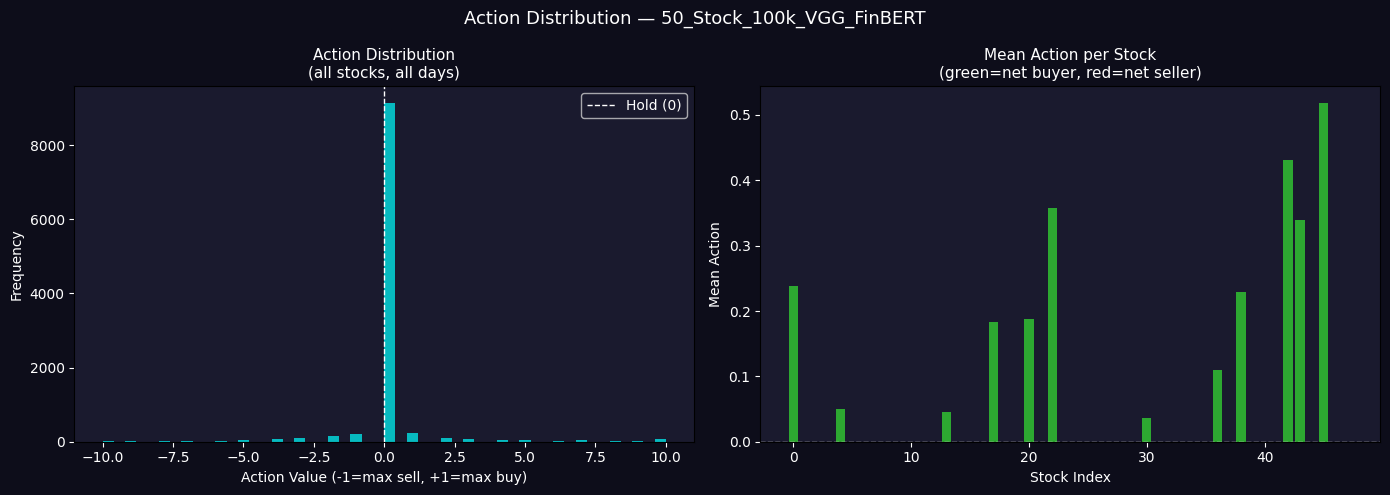

LOOK-AHEAD BIAS ANALYSIS

Pipeline:
  Polygon news date t  -> raw sentiment score for date t
  shift(1) applied     -> sentiment moved to date t+1
  Model trades date t  -> uses sentiment from date t-1

Result: NO look-ahead bias — news from date t informs
  trading decisions on date t+1 only.

First sentiment row per ticker is 0: True
CONFIRMED — shift(1) correctly applied

Sample rows for AAPL:
      date  tic  sentiment
2024-01-02 AAPL   0.000000
2024-01-03 AAPL  -0.037306
2024-01-04 AAPL  -0.149103
2024-01-05 AAPL  -0.128703
2024-01-08 AAPL  -0.050538
2024-01-09 AAPL   0.023295
2024-01-10 AAPL   0.062512
2024-01-11 AAPL  -0.011521
2024-01-12 AAPL   0.144166
2024-01-16 AAPL   0.235959
(First row should be 0.0 — no prior day sentiment)
Buy-and-Hold: 48 stocks, $2,083 per stock

  BUY-AND-HOLD METRICS
  Total Return (%)               25.53
  Sharpe Ratio                   1.437
  Max Drawdown (%)                -7.8
  Win Rate (%)                   56.97
  Avg Daily Return (%)        

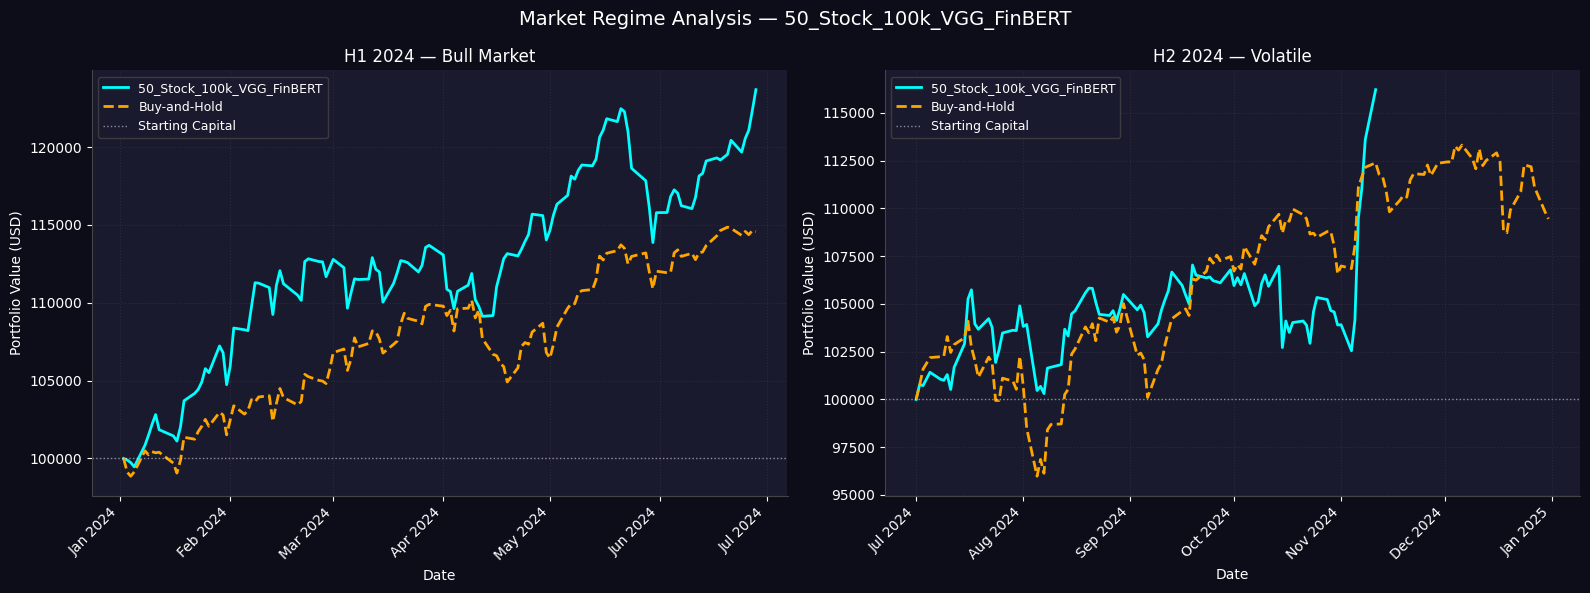

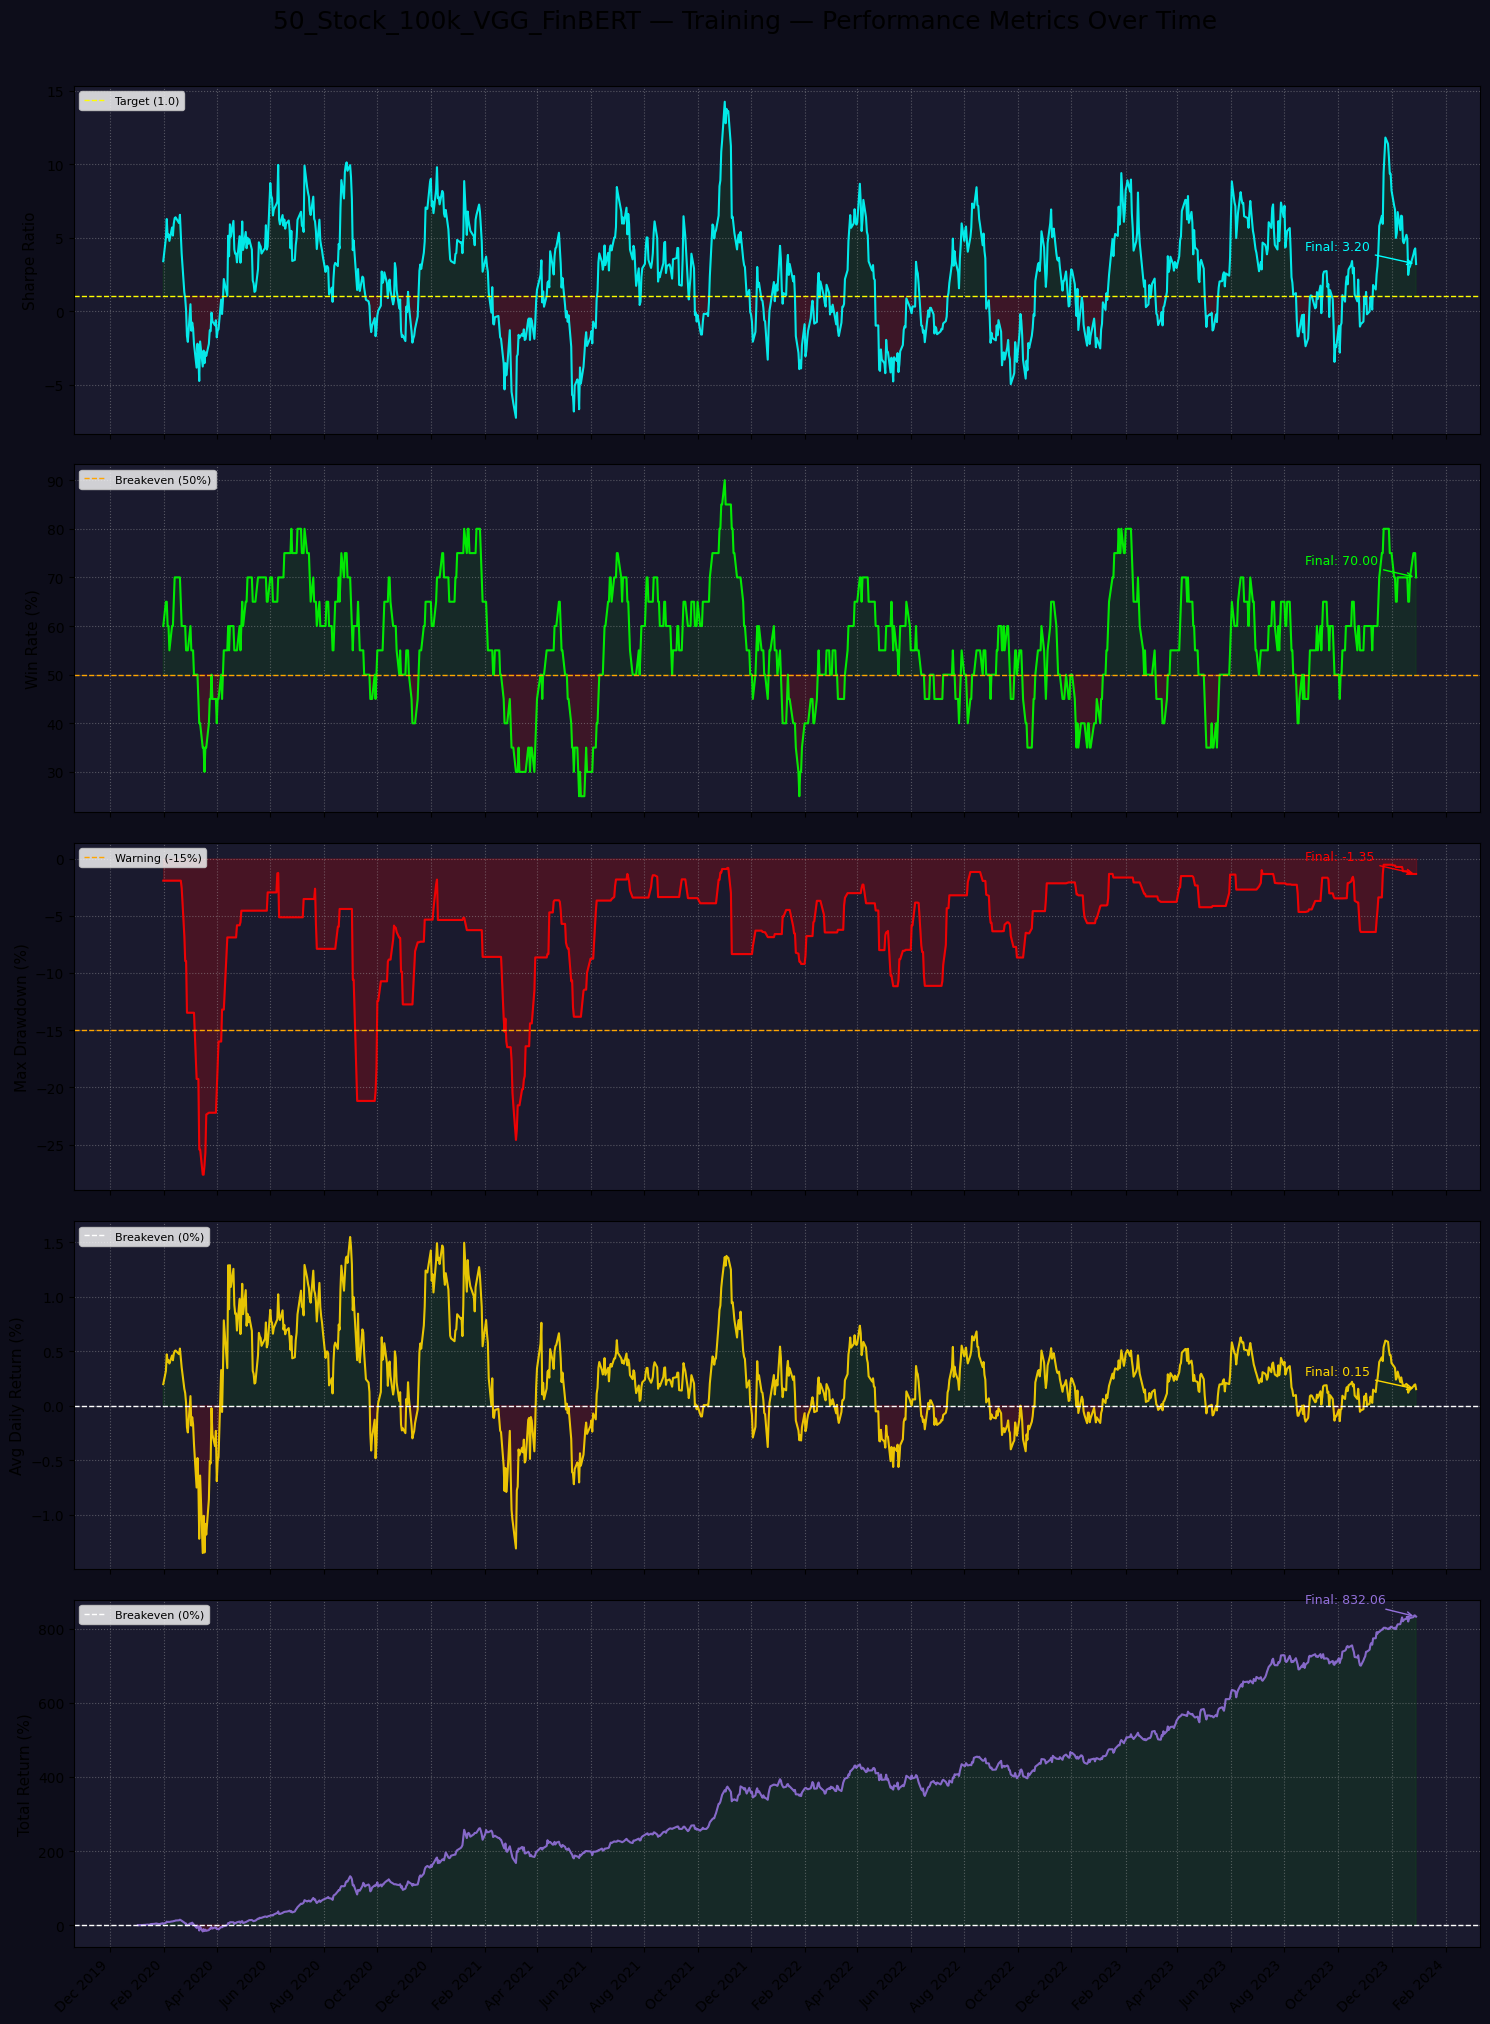


  50_STOCK_100K_VGG_FINBERT — TRAINING — FINAL METRIC VALUES
  Sharpe Ratio                   2.365  (avg)
  Win Rate (%)                  56.643  (avg)
  Max Drawdown (%)              -5.914  (avg)
  Avg Daily Return (%)           0.245  (avg)
  Total Return (%)             832.064  (final)


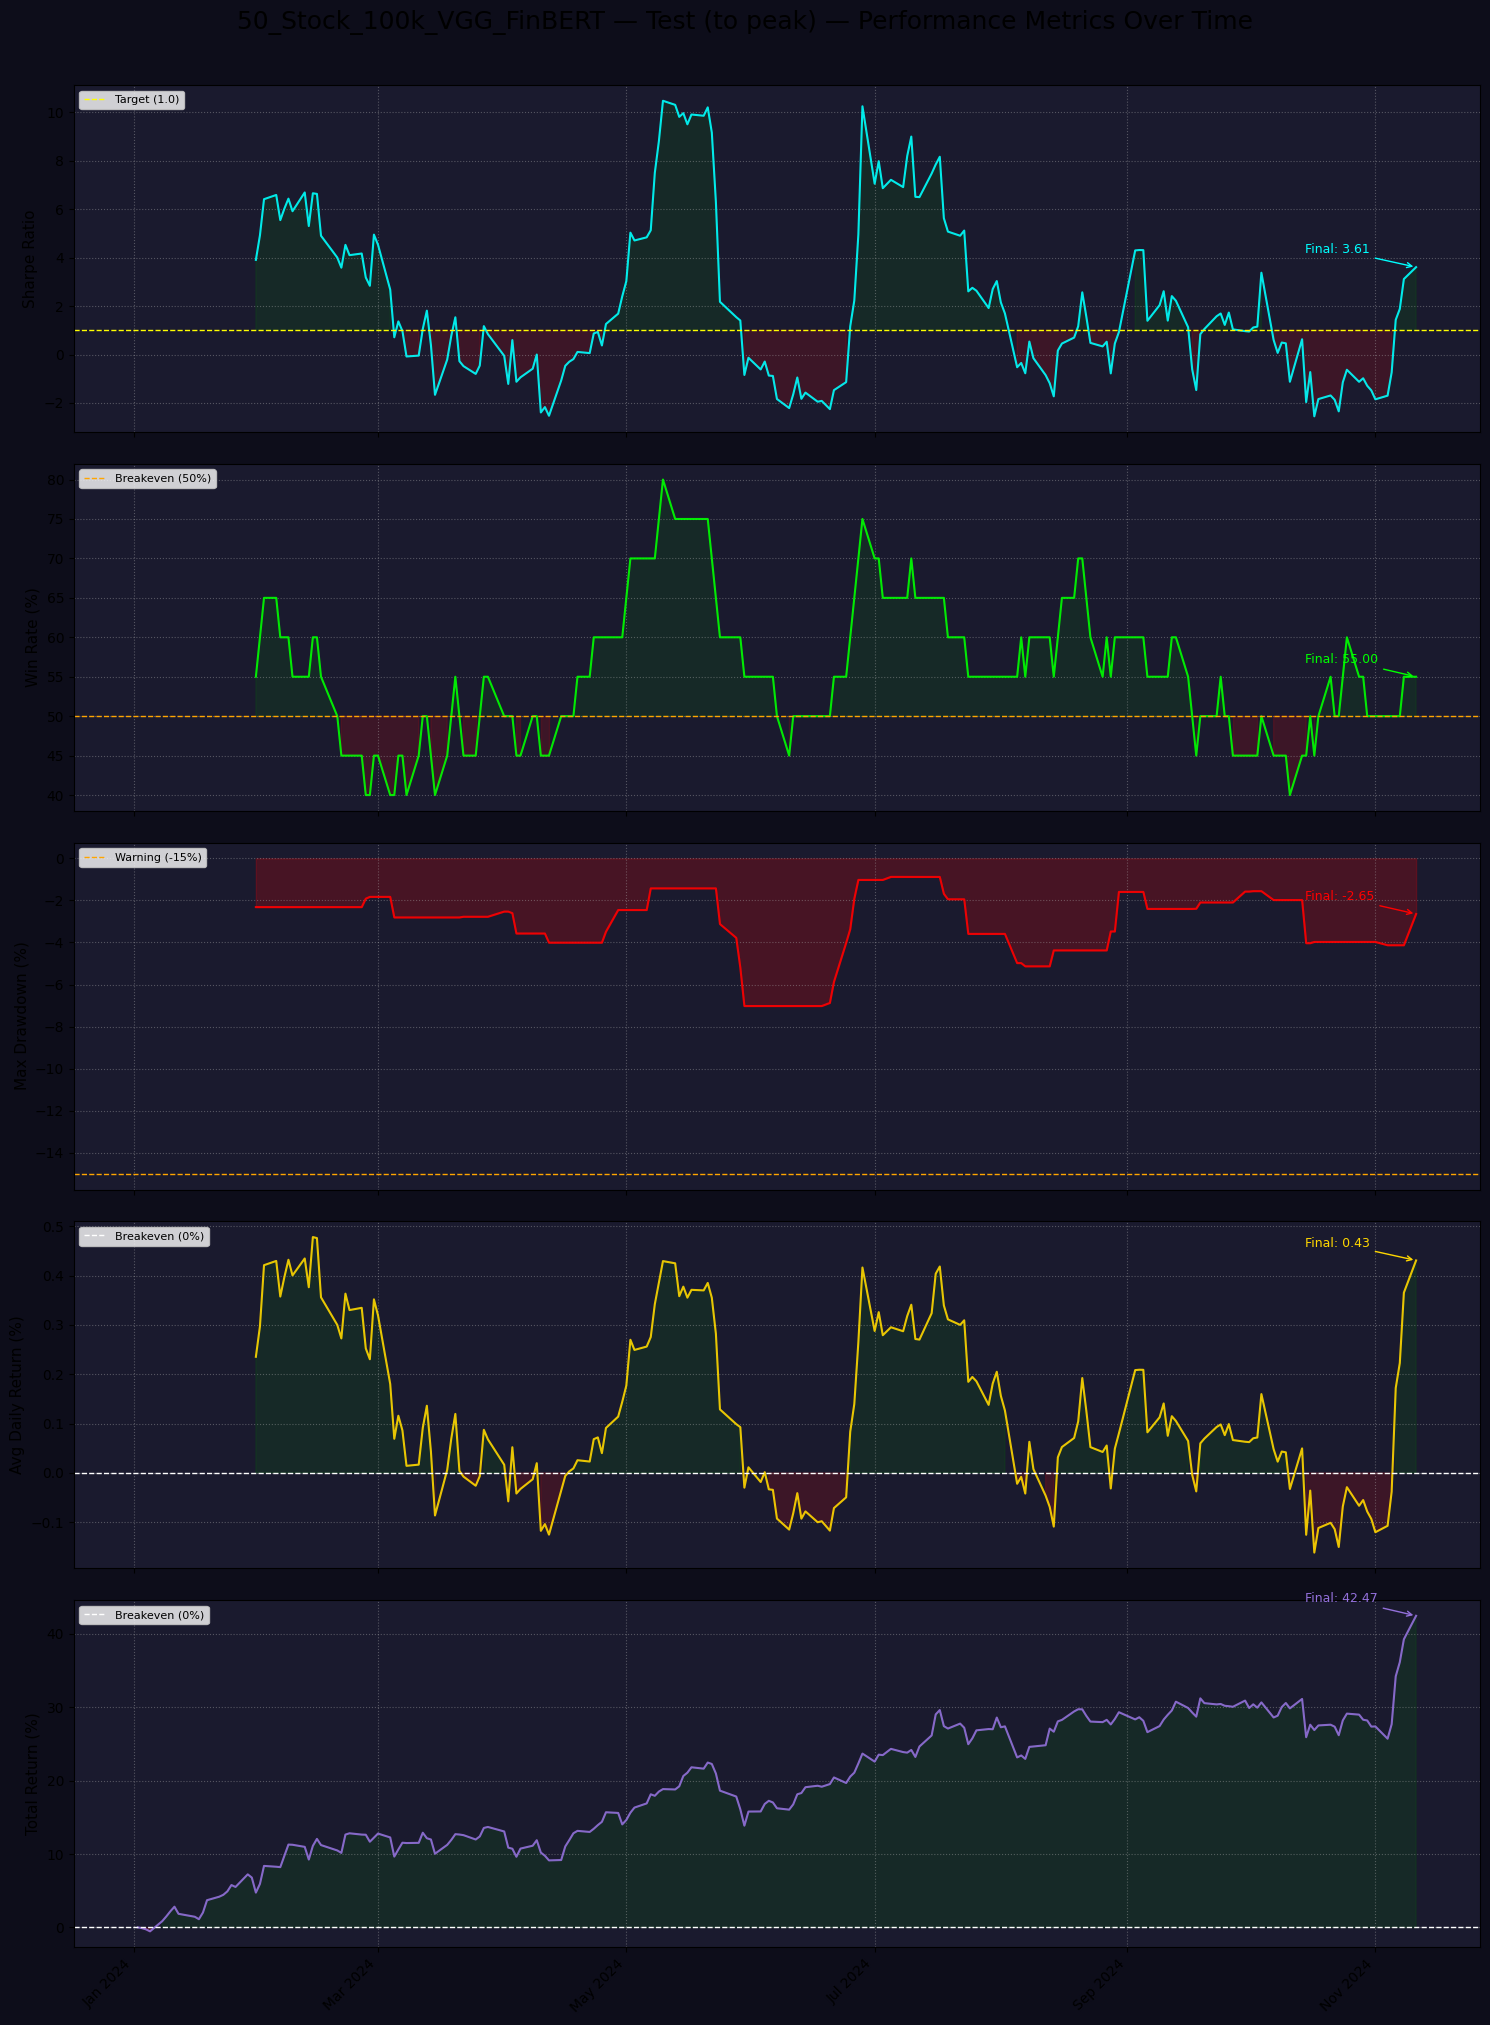


  50_STOCK_100K_VGG_FINBERT — TEST (TO PEAK) — FINAL METRIC VALUES
  Sharpe Ratio                   2.089  (avg)
  Win Rate (%)                  55.556  (avg)
  Max Drawdown (%)              -3.119  (avg)
  Avg Daily Return (%)           0.122  (avg)
  Total Return (%)              42.473  (final)

Pkl files saved: 6 files
Metrics summary: ./overlay_data/50_Stock_100k_VGG_FinBERT_metrics_summary.txt

  EVALUATION COMPLETE — 50_Stock_100k_VGG_FinBERT



In [13]:
# ── Sentiment notebooks ───────────────────────────────────────
results = run_full_evaluation(
    trained_model   = trained_vgg,
    e_train_gym     = e_train_gym,
    e_test_gym      = e_test_gym,
    df_test         = df_test,
    model_name      = 'VGG_FinBERT',   # change per notebook
    universe        = '50_Stock',
    capital         = '100k',
    initial_capital = 100_000,
    has_sentiment   = True             # True for all sentiment models
)